# import libraries

In [1]:
# Heart Disease Prediction Project

# ==============================
# Import Libraries
# ==============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import pickle


# load dataset

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   29    1   2       102   452    0        0       73      0      0.0      1   
1   34    1   2        99   465    0        0       85      0      0.0      1   
2   34    0   3       147   368    0        1      145      0      0.7      2   
3   35    0   2        99   513    0        0       83      0      1.4      1   
4   35    1   3       150   243    0        1      135      0      0.0      2   

   ca  thal  prediction  
0   0     3           0  
1   0     3           0  
2   0     4           1  
3   0     3           0  
4   0     4           1  


In [4]:
# ==============================
# EDA
# ==============================
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
prediction    0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         303 non-null    int64  
 1   sex         303 non-null    int64  
 2   cp          303 non-null    int64  
 3   trestbps    303 non-null    int64  
 4   chol        303 non-null    int64  
 5   fbs         303 non-null    int64  
 6   restecg     303 non-null    int64  
 7   thalach     303 non-null    int64  
 8   exang       303 non-null    int64  
 9   oldpeak     303 non-null    float64
 10  slope       303 non-null    int64  
 11  ca          303 non-null    int64  
 12  thal        303 non-null    int64  
 13  prediction  303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


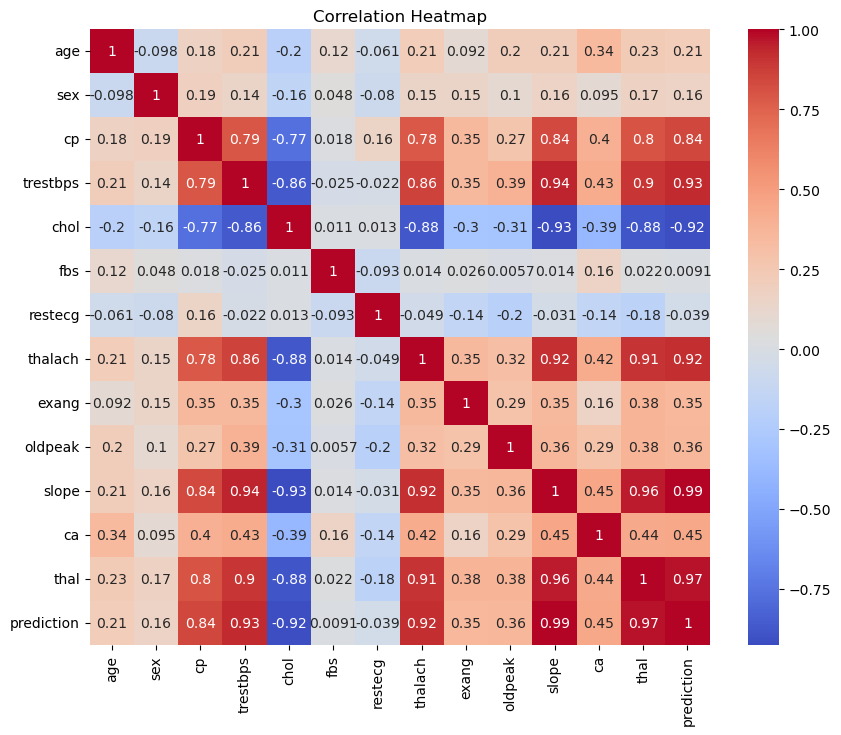

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


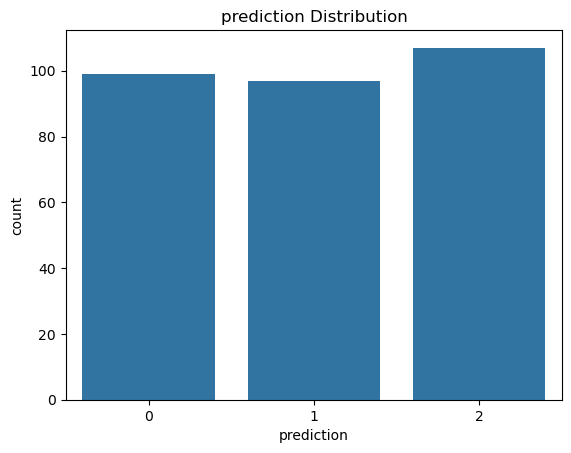

In [8]:
# Target Distribution
sns.countplot(x='prediction', data=df)
plt.title("prediction Distribution")
plt.show()

# data preprocessing

In [9]:
X = df.drop("prediction", axis=1)
y = df["prediction"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# ==============================
# Models
# ==============================

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)

}


In [16]:
# ==============================
# Training & Evaluation
# ==============================
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    


===== Logistic Regression =====
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        25

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        25

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61


===== Decision Tree =====
Accuracy: 0.9836065573770492
Classification Report:
               precision    recall  f1-score   sup

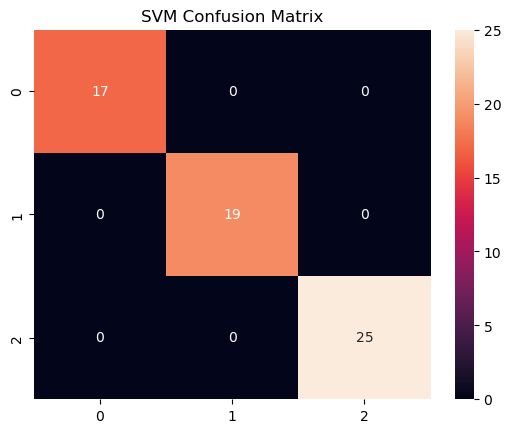

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"{name} Confusion Matrix")
plt.show()

In [22]:
 # ROC-AUC
from sklearn.metrics import roc_auc_score

# Get probabilities for all classes
y_prob = model.predict_proba(X_test)

# Compute ROC-AUC for multi-class
auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print("ROC-AUC:", auc)


ROC-AUC: 1.0


In [23]:
# ==============================
# Hyperparameter Tuning (Random Forest)
# ==============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print("\nBest Parameters:", grid.best_params_)
best_model = grid.best_estimator_



Best Parameters: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [24]:
# Evaluate Best Model
y_pred = best_model.predict(X_test)
print("\nFinal Model Accuracy:", accuracy_score(y_test, y_pred))



Final Model Accuracy: 1.0


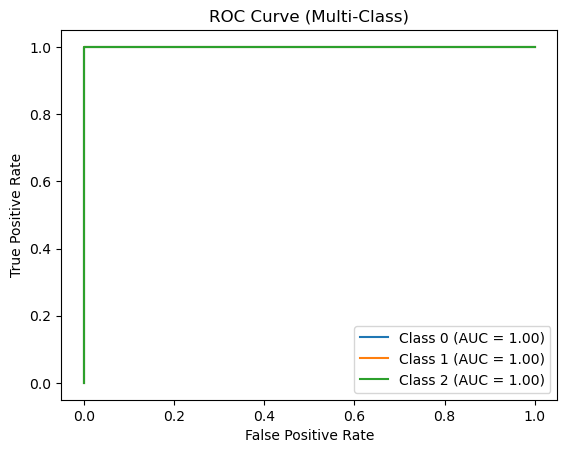

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Convert target to binary format
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

# Get probabilities
y_prob = model.predict_proba(X_test)

# Plot ROC curve for each class
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()

In [33]:
# ==============================
# Save Model
# ==============================
with open("heart_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model Saved Successfully!")


Model Saved Successfully!
